### Build chatbot

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [4]:
graph_builder

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
# from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chat_models import init_chat_model


# llm = ChatGroq(model="whisper-large-v3-turbo")
llm = ChatGoogleGenerativeAI(model='gemini-3.8-flash')
llm

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={}, google_api_key=SecretStr('**********'), model='gemini-3.8-flash', temperature=None, client=<google.genai.client.Client object at 0x00000207893DABA0>, default_metadata=(), model_kwargs={})

In [14]:
# llm = init_chat_model("qroq:meta-llama/llama-prompt-guard-2-22m")
# llm

In [7]:
### Node Functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

## Add Node
graph_builder.add_node("llmchatbot", chatbot)

## Add Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## Compile the graph
graph = graph_builder.compile()

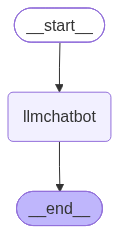

In [9]:

## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response = graph.invoke({"messages": "Hi"})

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [11]:
response["messages"][-1].content

[{'type': 'text',
  'text': 'Hello! How can I help you today?',
  'extras': {'signature': 'EtEBCs4BAWkUfROkg9XDi2Fsidv8oRQJlwTXACORB2Am3124HV2Pb6i9WgxDyyXBhrGg/vaos+Fb4v+IdtBsmiLEbEW/1VEtx3Eq8wqoVbGVcLunoEPjr7UunH4WarIhj3sm8Rmb05PoalKLtIxwudjuI22QEXe70cMqeW8y+4JXFiBJicIQgyP13ODf4F+nZn8IqbJkiF5SOZzYkFJ7m8CBpPYY9hW9A61mCRaykontGXNRRLGQdVMKor8qtfmPlH9Et2L70KGiRtswfFE2GLfB0Cw='}}]

In [12]:
for event in graph.stream({"messages": "Hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

[{'type': 'text', 'text': "Hello! I'm doing well, thank you for asking. How are you doing today? How can I help you?", 'extras': {'signature': 'EssECsgEAWkUfRNByLbPABM7IzjHzVmWz1k4mmW3e6f1xAJ+Lup4oJuin2jqE2tst4wXIuN3k6ZBaJ9lJNfcQ0CZVAJ4ySqfUWLqrn1bKFncpbO9cjtuhXdwb+E8tw4nOrqq8FxBiAjm+/t3BhSkbLBTeHDyYtXwkbuhuHW1zqJIvz0H+QGkXbnyVND5OXSw8G3iHp6LsZTr5HxbntotKx1rL/L4tibSb6FGesMUCouykz3pKCY4LbCnu7JoFyAeoGo2i4UTkbiXJoq+IMqldx+2qJ/giDlkkeEZN7Zdbv7D8ShFwJ7Wt3101AAqEsnkc/pMDOCVzqb4CBH+18RrqdyuWcb6wdVmOsE06DO78GVSbTC42ZbT7ThEMxcNqUJBblpEDyyJdpNT/AIcZ6zdXMnJiF6ZHt9O9a6MSZRa+cvspCIG5rygIqoAco2IqDPtOAsd2DTe/MyPXGCYANDSFl8yARYjBZg4sayM/HTuFvi6VDSp9K6RnfkgSnGc4AbFY8eKNgIEdloTdMHr6JGYwS0ls0Dwri2J30bDfo4UamjdQ+0/gMVwO2BYsHtJPMtoHP+3TvOhUrW3R/3q6va7cH1rGsB4MZyIXYsi8dXONSXI7mSnozx1eTHCoFRYg8yRnDXUTEa27bNFdJW1UJUdPeM0FBu0h2/gB1fsOBBUR1N56Nq0cQ0jhB6ejU+vvRaIocHKU4RbPLPBSl8P9Zdi8xivbqsb8JLWp1QJQTFCXqxDz9t1EXizShNk2h5PPskrn1HD2m2HjrNzRoHDWjM='}}]


### Chatbot With Tool

In [21]:
# # from langchain_tavily import TavilySearch
# from langchain_community.utilities import TavilySearchAPIWrapper

# # Leave the API key blank—Tavily's server will automatically route it to the free keyless tier
# search = TavilySearchAPIWrapper(tavily_api_key="")
# response = search.results("What is the latest tech news today?")
# print(response)
# # tool = TavilySearch(max_results=2)
# # tool.invoke("What is langgraph?")

### Custom Tools

In [13]:
from langchain.tools import tool

In [14]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: First int
        b: Second int
    """
    return a * b

In [15]:
tools = [multiply]

In [16]:
llm_with_tool = llm.bind_tools(tools)

In [17]:
llm_with_tool

_ChatModelBinding(bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={}, google_api_key=SecretStr('**********'), model='gemini-3.8-flash', temperature=None, client=<google.genai.client.Client object at 0x00000207893DABA0>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b.\n\nArgs:\n    a: First int\n    b: Second int', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}]}, config={}, config_factories=[])

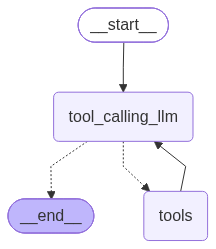

In [26]:
### Stategraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


### Node Definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")

### Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
response = graph.invoke({"messages": "What is 2 times 5?"})

In [24]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 times 2?
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (call_45795)
 Call ID: call_45795
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4
================================== Ai Message ==================================

[{'type': 'text', 'text': '2 times 2 is 4.', 'extras': {'signature': 'EqQBCqEBAWkUfRPJ6zeGMpVZ5ZL+f+C6TciTrMmxvlkJ3mHrCw0BHDddtG7aHzcrmXQkTYtDcusXroOxEnK8Oc9Efp0xCaL3ci3qHJ25NxJNTP+mQ7AiFLb/UKc2uLr91qYbC/qOdxqx+uJmKOaRCDUAsq+6OYb35YdJ8fUGWJomV7opUyqp/oYdGLvLWHqqPU86PWam3FTL1ZBkiFIO+9WHK2/WZks='}}]
